<a href="https://colab.research.google.com/github/antonclayton/CS166_phishing_classification/blob/main/CS166_PhishingClassification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS166 - Phishing Email Classification Project
This project aims to develop machine learning models to detect phishing emails more reliably than traditional spam filters. We will clean raw email text, convert it to numerical features using TF-IDF, and then train and compare Logistic Regression, Random Forest, and a simple neural network (LSTM) model. The goal is to identify patterns and writing styles characteristic of phishing attempts.

### 1. Load Data
Add Shortcuts: Crucial Step! Every group member must go to their Google Drive "Shared with me" section, right-click the shared folder, and select "Add shortcut to Drive."

Tip: Everyone should place the shortcut directly in the root of their "My Drive" and name it exactly the same thing: `CS166_Phishing`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Define the path to the folder and the file
folder_path = '/content/drive/MyDrive/CS166_Phishing'
file_name = 'Phishing_Email.csv'
file_path = f'{folder_path}/{file_name}'

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_name}' from '{folder_path}'.")
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found at '{folder_path}'. Please check the folder and file name.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded 'Phishing_Email.csv' from '/content/drive/MyDrive/CS166_Phishing'.


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


#### Dataset Features
The dataset is a single CSV file with the following 2 columns:

- Email Text: The full body of the email.
- Email Type: "Safe Email" or "Phishing Email"

### 2. Dataset Exploration
- Also, map "Safe Email" and "Phishing Email" labels to numbers 0 and 1 respectively

In [ ]:
# Display the first 5 rows
print("First 5 rows of the DataFrame:")
display(df.head())

# Display column names and their data types
print("\nColumn names and data types:")
display(df.info())

# Check the number of rows and columns
print("\nShape of the DataFrame (rows, columns):")
display(df.shape)

# Display descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Clean df
df_clean = df.dropna(subset=['Email Text', 'Email Type']).copy()

# Encode labels to binary (0 = Safe, 1 = Phishing)
df_clean['Label'] = df_clean['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

First 5 rows of the DataFrame:


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email



Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


None


Shape of the DataFrame (rows, columns):


(18650, 3)


Descriptive statistics:


,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000



Missing values per column:


,0
Unnamed: 0,0
Email Text,16
Email Type,0


### 3. Data Cleaning and Preprocessing
- Clean the email text data by performing stemming and other necessary text cleaning steps.
- Handle missing values, convert text to lowercase, remove special characters and numbers, and apply stemming to the email text.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

df_clean['Email Text'] = df['Email Text'].fillna('')
df_sampled = df_clean.copy()

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Add dataset-specific stopwords
# To remove quirks from Enron and Ling-Spam datasets
custom_email_stopwords = [
    # Enron Artifacts
    'enron', 'ect', 'ees', 'ena', 'corp', 'houston', 'hou',
    'vince', 'kaminski', 'shirley', 'crenshaw', 'kenneth', 'lay',
    'jeff', 'skilling', 'fastow', 'dasovich', 'jones', 'smith', 'louis', 'sep'
    'issu'

    # Ling-Spam Artifacts
    'linguist', 'linguistics', 'linguistic', 'language', 'university', 'symposium',
    'conference', 'paper', 'abstract', 'deadline', 'submit', 'publish', 'edu',

    # Structural/Formatting Metadata
    'fw', 'fwd', 'cc', 'bcc', 'pm', 'am', 'sent', 'wrote', 'mailto',
    'subject', 're', 'message', 'original', 'date', 'from', 'to', 'http', 'https', 'url',

    # Common Corporate Filler
    'thanks', 'regards', 'best', 'attached', 'meeting', 'schedule', 'group', 'vinc'

    # Other
    'httpwwwnewsisfreecomclick'
]

stop_words.update(custom_email_stopwords)

# Compile regex patterns for years and special characters
year_regex = re.compile(r'\b(?:19|20)\d{2}\b')
regex = re.compile(r'[^a-z\s]')

def clean_and_stem_text(text):
    text = text.lower()
    text = year_regex.sub('', text)
    text = regex.sub('', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

tqdm.pandas()
df_sampled['Cleaned Email Text'] = df_sampled['Email Text'].progress_apply(clean_and_stem_text)

100%|██████████| 18634/18634 [01:20<00:00, 230.63it/s]


In [ ]:
display(df_sampled[['Email Text', 'Cleaned Email Text']].head())

,Email Text,Cleaned Email Text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarian sex lang dick hudson obser...
1,the other side of * galicismos * * galicismo *...,side galicismo galicismo spanish term name imp...
2,re : equistar deal tickets are you still avail...,equistar deal ticket still avail assist robert...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horni toy one dream open mind pe...
4,software at incredibly low prices ( 86 % lower...,softwar incred low price lower draperi sevente...


### 4. TF-IDF Vectorization and Data Splitting

Split the data into training and testing sets, and then apply TF-IDF vectorization to the email text content. This converts the text into numerical feature vectors that can be used by machine learning models.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df_sampled['Cleaned Email Text']
y = df_sampled['Label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TF-IDF Vectorization
# We limit max_features to 5000 to keep the models fast, and remove standard english stop words
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Create separate variables for the TF-IDF matrices
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"TF-IDF Training data shape: {X_train_tfidf.shape}")
print(f"TF-IDF Testing data shape: {X_test_tfidf.shape}")

TF-IDF Training data shape: (14907, 5000)
TF-IDF Testing data shape: (3727, 5000)


### Classification Models
- Logistic Regression
- Random Forest
- LSTM Neural Network

### 5. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)

print("--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=['Safe', 'Phishing']))

--- Logistic Regression Results ---
Accuracy: 0.9555

              precision    recall  f1-score   support

        Safe       0.96      0.97      0.96      2209
    Phishing       0.95      0.94      0.94      1518

    accuracy                           0.96      3727
   macro avg       0.95      0.95      0.95      3727
weighted avg       0.96      0.96      0.96      3727



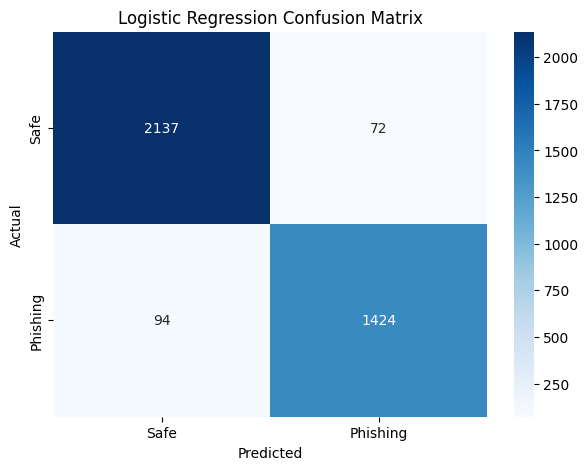

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute and plot Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Feature Importance (LOGISTIC REGRESSION): Word Weights
Analyze which words the Logistic Regression model relies on most to classify emails.

In [ ]:
import pandas as pd

# Get the feature names from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the coefficients from the logistic regression model
# These represent the 'weight' or importance of each word
coefficients = lr_model.coef_[0]

# Create a DataFrame to store feature names and their corresponding coefficients
feature_importance = pd.DataFrame({'word': feature_names, 'weight': coefficients})

# Sort by weight to see the most influential words
print("Top 10 words indicating a PHISHING email (Highest positive weights):")
display(feature_importance.sort_values(by='weight', ascending=False).head(10))

print("\nTop 10 words indicating a SAFE email (Highest negative weights):")
display(feature_importance.sort_values(by='weight', ascending=True).head(10))

Top 10 words indicating a PHISHING email (Highest positive weights):


,word,weight
3749,remov,5.375254
806,click,5.059136
2914,money,3.863089
1791,free,3.816835
2809,medic,3.373841
2244,info,3.289850
3937,save,3.288419
2596,life,3.154551
2319,invest,3.070241
4142,softwar,3.055408



Top 10 words indicating a SAFE email (Highest negative weights):


,word,weight
2122,httpwwwnewsisfreecomclick,-5.198636
1274,discuss,-3.822277
3774,research,-3.394189
2670,louis,-3.384641
2176,im,-3.220502
4003,sep,-2.947976
1469,english,-2.858856
3615,question,-2.823190
2355,issu,-2.766331
1447,employe,-2.736569


### 6. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Initialize and train Random Forest
# n_estimators=100 means it will build 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_tfidf)

print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['Safe', 'Phishing']))

--- Random Forest Results ---
Accuracy: 0.9573

              precision    recall  f1-score   support

        Safe       0.97      0.96      0.96      2209
    Phishing       0.94      0.95      0.95      1518

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



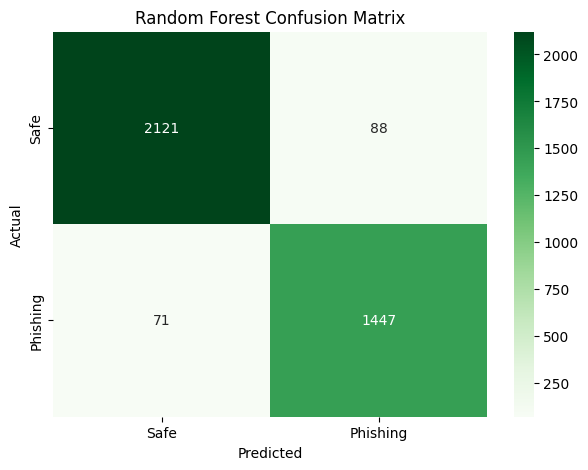

In [ ]:
# Confusion Matrix (visualization)
# Compute and plot Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Feature Importance (RANDOM FOREST): Word Weights
Analyze which words the Random Forest model relies on most to classify emails.

In [ ]:
import pandas as pd

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Get feature importances from the RF model
importances = rf_model.feature_importances_

# Create a DataFrame
rf_importance = pd.DataFrame({'word': feature_names, 'importance': importances})

# Sort by importance
print("Top 20 most important words for the Random Forest model:")
display(rf_importance.sort_values(by='importance', ascending=False).head(20))

Top 20 most important words for the Random Forest model:


,word,importance
806,click,0.028525
3749,remov,0.020040
3122,offer,0.014299
2914,money,0.012025
3937,save,0.010223
863,com,0.009759
1274,discuss,0.009417
3143,onlin,0.009194
1791,free,0.009009
1448,empti,0.007182


### 7 LSTM (Neural Network)

#### 7.1 Tokenize:
Tokenize the cleaned text into words and then generate N-grams (sequences of N words) from the tokens. This will capture the sequential nature of the text for the LSTM model. Will create both unigrams (N=1) and bigrams (N=2).

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

df_LSTM = df_sampled.copy();

# Define the vocabulary size
vocab_size = 10000

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

# Fit the tokenizer on the cleaned text
tokenizer.fit_on_texts(df_LSTM['Cleaned Email Text'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df_LSTM['Cleaned Email Text'])

# Let's see an example of sequences
print("Example of text to sequences:")
print(sequences[0])

Example of text to sequences:
[2750, 1, 969, 2233, 3000, 4386, 1403, 26, 3, 1, 1, 1, 281, 2226, 2101, 1913, 1372, 24, 1269, 791, 5, 210, 133, 775, 3, 2681, 73, 1, 486, 1281, 165, 620, 3344, 1269, 791, 2022, 2681, 292, 274, 88, 1281, 1001, 274, 1269, 791, 179, 3, 4533, 886, 563, 13, 182, 32, 1944, 15, 586, 909, 2138, 521, 2183, 2482, 274, 165, 2183, 24, 663, 1913, 605, 1913, 5, 24, 1913, 1913, 95, 760, 955, 2439, 5, 184, 2091, 3279, 421]


#### 7.2 Add padding to input sequences and create train/test split
- The LSTM model requires input sequences of a fixed length. Use padding to ensure all sequences have the same length.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine the maximum sequence length
# Truncating to a maximum length for faster processing
max_sequence_length = 500 # Reduced maximum sequence length
print(f"Maximum sequence length (after truncation): {max_sequence_length}")

# Pad the sequences
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')

# Prepare labels
# Convert 'Email Type' to numerical labels (0 for Safe Email, 1 for Phishing Email)
label_mapping = {'Safe Email': 0, 'Phishing Email': 1}
labels = df_LSTM['Email Type'].map(label_mapping).values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

print("\nShape of padded sequences:", padded_sequences.shape)
print("Shape of labels:", labels.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Maximum sequence length (after truncation): 500

Shape of padded sequences: (18634, 500)
Shape of labels: (18634,)
Shape of X_train: (14907, 500)
Shape of X_test: (3727, 500)
Shape of y_train: (14907,)
Shape of y_test: (3727,)


#### 7.3 Build LSTM model
- A simple RNN model using TensorFlow's Keras API. The model consists of an Embedding layer to handle the numerical representations of the N-grams, followed by a SimpleRNN layer and a Dense output layer for classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM # Import LSTM

# Define model parameters
embedding_dim = 128 # Dimension of the embedding vector
rnn_units = 64     # Number of units in the RNN layer

# Build the RNN model
model = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(rnn_units), # LSTM
    Dropout(0.3), # Add dropout for regularization
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### 7.4 Train LSTM

In [ ]:
history = model.fit(X_train, y_train, epochs=15, validation_split=0.2)

Epoch 1/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6182 - loss: 0.6668 - val_accuracy: 0.6160 - val_loss: 0.6660
Epoch 2/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6390 - loss: 0.6490 - val_accuracy: 0.6201 - val_loss: 0.6537
Epoch 3/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6310 - loss: 0.6403 - val_accuracy: 0.6190 - val_loss: 0.6579
Epoch 4/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.6335 - loss: 0.6367 - val_accuracy: 0.6204 - val_loss: 0.6622
Epoch 5/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6345 - loss: 0.6314 - val_accuracy: 0.6190 - val_loss: 0.6606
Epoch 6/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6350 - loss: 0.6309 - val_accuracy: 0.6214 - val_loss: 0.6567
Epoch 7/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6305 - loss: 0.6384 - val_accuracy: 0.6197 - val_loss: 0.6591
Epoch 8/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6351 - loss: 0.6318 - val_acc

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get predictions on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32") # Convert probabilities to binary predictions

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy: 0.9520
Precision: 0.9339
Recall: 0.9493
F1-score: 0.9415


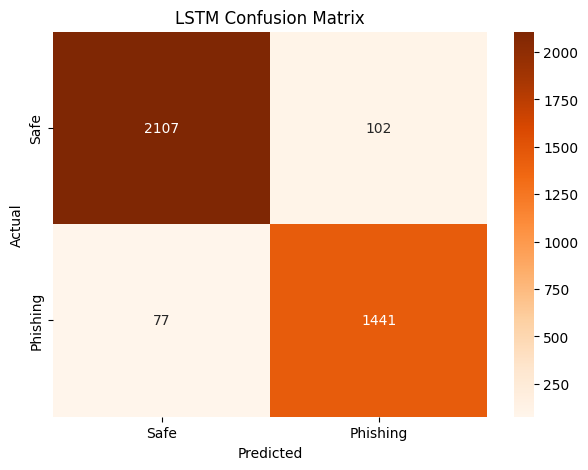

In [ ]:
# Compute the confusion matrix for the LSTM model
cm_lstm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 8. Test on another dataset
- It is very likely that our current models are "overfitted" on the dataset and perform exceptionally well because it has "memorized" the current dataset.
- Therefore, we must also test our models on unseen data (in this case a new phishing dataset)

In [ ]:
# Define the path to the folder and the file
folder_path = '/content/drive/MyDrive/CS166_Phishing'
file_name = 'phishing_dataset_10000.csv'
file_path = f'{folder_path}/{file_name}'

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_name}' from '{folder_path}'.")
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found at '{folder_path}'. Please check the folder and file name.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded 'phishing_dataset_10000.csv' from '/content/drive/MyDrive/CS166_Phishing'.


,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


#### 8.1 Preprocess the New Dataset
We need to apply the same cleaning and transformation steps (TF-IDF for traditional models and Tokenization/Padding for LSTM) that we used on the training data.

In [ ]:
# Clean the new dataset text
df['Cleaned Text'] = df['text'].progress_apply(clean_and_stem_text)

# Prepare features for LR and RF (TF-IDF)
X_new_tfidf = tfidf.transform(df['Cleaned Text'])

# Prepare features for LSTM (Tokenization and Padding)
new_sequences = tokenizer.texts_to_sequences(df['Cleaned Text'])
X_new_padded = pad_sequences(new_sequences, maxlen=max_sequence_length, padding='post', truncating='post')

# Prepare labels (assuming 'label' column matches our 0/1 mapping)
y_new = df['label']

100%|██████████| 10000/10000 [00:03<00:00, 2515.64it/s]


#### 8.2 Evaluate Models on New Data

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Logistic Regression Prediction
y_pred_lr_new = lr_model.predict(X_new_tfidf)
print("--- Logistic Regression Performance on New Dataset ---")
print(f"Accuracy: {accuracy_score(y_new, y_pred_lr_new):.4f}")
print(classification_report(y_new, y_pred_lr_new))

# 2. Random Forest Prediction
y_pred_rf_new = rf_model.predict(X_new_tfidf)
print("\n--- Random Forest Performance on New Dataset ---")
print(f"Accuracy: {accuracy_score(y_new, y_pred_rf_new):.4f}")
print(classification_report(y_new, y_pred_rf_new))

# 3. LSTM Prediction
y_pred_lstm_prob = model.predict(X_new_padded)
y_pred_lstm_new = (y_pred_lstm_prob > 0.5).astype("int32")
print("\n--- LSTM Performance on New Dataset ---")
print(f"Accuracy: {accuracy_score(y_new, y_pred_lstm_new):.4f}")
print(classification_report(y_new, y_pred_lstm_new))

--- Logistic Regression Performance on New Dataset ---
Accuracy: 0.7586
              precision    recall  f1-score   support

           0       0.62      0.99      0.77      4000
           1       0.99      0.60      0.75      6000

    accuracy                           0.76     10000
   macro avg       0.81      0.80      0.76     10000
weighted avg       0.85      0.76      0.76     10000


--- Random Forest Performance on New Dataset ---
Accuracy: 0.5497
              precision    recall  f1-score   support

           0       0.47      0.92      0.62      4000
           1       0.85      0.30      0.44      6000

    accuracy                           0.55     10000
   macro avg       0.66      0.61      0.53     10000
weighted avg       0.70      0.55      0.52     10000

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

--- LSTM Performance on New Dataset ---
Accuracy: 0.6844
              precision    recall  f1-score   support

           0       0.56      0.98      0.71      400

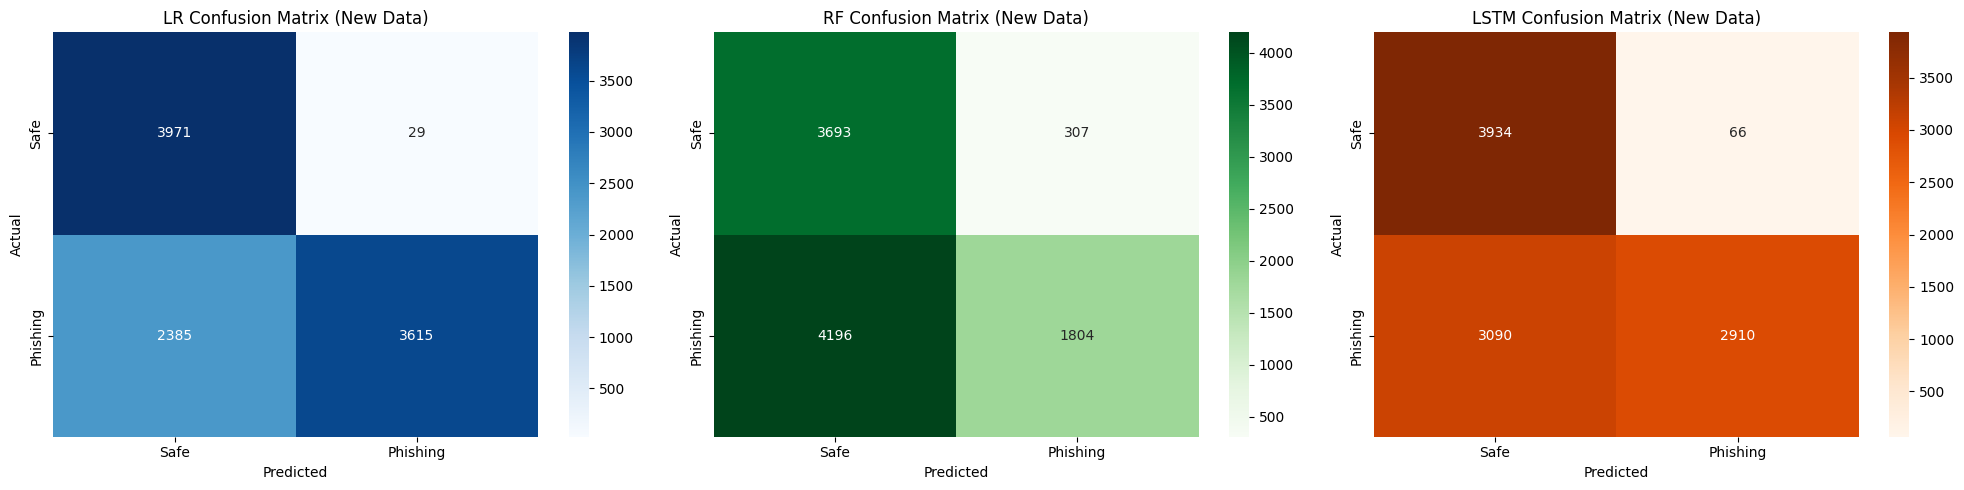

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices for the new dataset
cm_lr_new = confusion_matrix(y_new, y_pred_lr_new)
cm_rf_new = confusion_matrix(y_new, y_pred_rf_new)
cm_lstm_new = confusion_matrix(y_new, y_pred_lstm_new)

# Set up the visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot Logistic Regression
sns.heatmap(cm_lr_new, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[0].set_title('LR Confusion Matrix (New Data)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot Random Forest
sns.heatmap(cm_rf_new, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[1].set_title('RF Confusion Matrix (New Data)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Plot LSTM
sns.heatmap(cm_lstm_new, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[2].set_title('LSTM Confusion Matrix (New Data)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 9. Fun Email Test


In [ ]:
# Define test emails
test_emails = [
    {
        "text": """Urgent: Your account has been compromised.
        Please click here to verify your identity and reset your password immediately:
        http://secure-login-verify.com/login""",
        "label": "Phishing",
        "expected": 1
    },
    {
        "text": """DEAR WINNER,
        you have won a cash prize of $1,000,000.00 in our international lottery.
        Contact our agent at win@prize-claims.net to claim your funds.""",
        "label": "Phishing",
        "expected": 1
    },
    {
        "text": """Hi team,
        just a reminder that our project sync is scheduled for tomorrow at 10 AM
        in the main conference room. See you there!""",
        "label": "Safe",
        "expected": 0
    }
]

# 1. Preprocess the emails
cleaned_test_emails = [clean_and_stem_text(email['text']) for email in test_emails]

# 2. Vectorize for LR and RF
X_test_tfidf_fun = tfidf.transform(cleaned_test_emails)

# 3. Tokenize and Pad for LSTM
test_sequences = tokenizer.texts_to_sequences(cleaned_test_emails)
X_test_padded_fun = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post', truncating='post')

# 4. Get Predictions
# Traditional Models
lr_preds = lr_model.predict(X_test_tfidf_fun)
rf_preds = rf_model.predict(X_test_tfidf_fun)

# LSTM Model
lstm_probs = model.predict(X_test_padded_fun)
lstm_preds = (lstm_probs > 0.5).astype("int32").flatten()

# 5. Display Results
results_df = pd.DataFrame({
    'Email Type': [e['label'] for e in test_emails],
    'Expected (0/1)': [e['expected'] for e in test_emails],
    'LR Prediction': lr_preds,
    'RF Prediction': rf_preds,
    'LSTM Prediction': lstm_preds
})

print("--- Model Comparison on Custom Emails ---")
display(results_df)

for i, email in enumerate(test_emails):
    print(f"\n--- Email {i+1} ---")
    print(f"Text: {email['text']}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
--- Model Comparison on Custom Emails ---


,Email Type,Expected (0/1),LR Prediction,RF Prediction,LSTM Prediction
0,Phishing,1,1,1,1
1,Phishing,1,1,1,1
2,Safe,0,0,0,0



--- Email 1 ---
Text: Urgent: Your account has been compromised.
        Please click here to verify your identity and reset your password immediately:
        http://secure-login-verify.com/login

--- Email 2 ---
Text: DEAR WINNER,
        you have won a cash prize of $1,000,000.00 in our international lottery.
        Contact our agent at win@prize-claims.net to claim your funds.

--- Email 3 ---
Text: Hi team,
        just a reminder that our project sync is scheduled for tomorrow at 10 AM
        in the main conference room. See you there!
